<a href="https://colab.research.google.com/github/ElaborateDesigns/BERN02/blob/main/Bern02_hierarchical_models_and_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.1/109.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.3/608.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.4/209.4 kB 10.9 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing in

We're studying towel reuse in hotels, if guests are told that the norm is to reuse towels (treatment group), vs if guests are told that reusing towels are good for the environment (control).

(A third group not being told anything would give good data, but alas there was none.)

We have access to an article about this problem. Unfortunately that seems to use the same data as us, otherwise I could piggyback on that data to make a *really good* prior.

The appropriate family distribution for a response variable p Binomial. The beta-binomial seems more forgiving.

With studies in different locations, there is likely a specific slope and intercept for each study location because of differing cultural values.



In [3]:
import pandas as pd
import numpy as np

#(This part copied from the excercise instructions without modification.)

# read in data
data_file = "towelData.csv"
data = pd.read_csv(data_file, sep=';', encoding='latin1')
count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 diferent studies

control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set
# can give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')

# See first rows
print(combined_data)

    reuse  total    group study
0      74    211  control     1
1     103    277  control     2
2      77    135  control     3
3      82    187  control     4
4      21     25  control     5
5     123    147  control     6
6      28     30  control     7
7      98    222   social     1
8     587   1318   social     2
9     406    655   social     3
10    278    555   social     4
11     21     24   social     5
12    472    576   social     6
13    101    132   social     7


The different studies were done in different countries, with different customs.

To get a stronger test, I divided the different studies into "US" and "non-US" countries.

In [4]:
#Adding data on study origin country, using information from article
# ( "Bayesian Evidence Synthesis Can Reconcile Seemingly Inconsistent Results: The Case of Hotel Towel Reuse",
# Psychological Science 2016, Vol. 27(7) 1043 –1046)

country_map = {
    1: "USA",       # Goldstein et al. 2008, Exp 1
    2: "USA",       # Goldstein et al. 2008, Exp 2
    3: "USA",       # Schultz et al. 2008, Exp 2
    4: "USA",       # Schultz et al. 2008, Exp 3
    #5: "Australia",  # Mair & Bergin-Seers 2010, Exp 1
    #6: "Germany",    # Bohner & Schlüter 2014, Exp 1
    #7: "Germany",    # Bohner & Schlüter 2014, Exp 2
    5: "non-US",  # Mair & Bergin-Seers 2010, Exp 1
    6: "non-US",    # Bohner & Schlüter 2014, Exp 1
    7: "non-US",    # Bohner & Schlüter 2014, Exp 2
}

combined_data["country"] = combined_data["study"].map(country_map).astype("category")


In [6]:
#()import arviz as az
# print(az.__version__)
import bambi as bmb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


#Null hypothesis: group has no impact on reuse.
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1.5),
    "1|country": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=0.5)),   # prior on the SD of study effects
}

model_null = bmb.Model("p(reuse, total) ~ 1 + (1|country)", combined_data, family="beta_binomial", priors=priors)
results_null = model_null.fit(draws=1000, target_accept=0.95, idata_kwargs={"log_likelihood": True})


#H1: group has same impact in all countries

priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1.5),
    "group": bmb.Prior("Normal", mu=0, sigma=1),                                   # one prior, one coefficient
    "1|country": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=0.5)),   # prior on the SD of study effects

}

# Initialize the fixed effects only model
model_hierarchical = bmb.Model("p(reuse, total) ~ 1 + group + (1|country)", combined_data, family="beta_binomial", priors=priors)
model_hierarchical

# Get model description
print(model_hierarchical)

# Fit the model using 1500 on each chain
results = model_hierarchical.fit(draws=1500, tune=1500, target_accept=0.95, idata_kwargs={"log_likelihood": True})


#H2: group has different impact in US and the rest of the world

priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1.5),
    "group": bmb.Prior("Normal", mu=0, sigma=1),                                   # one prior, one coefficient
    "1|country": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=0.5)),   # prior on the SD of study effects

}
model_interaction = bmb.Model(
    "p(reuse, total) ~ 1 + group * country + (1|country)",
    combined_data, priors = priors,
    family="beta_binomial"
)
model_interaction
results_interaction = model_interaction.fit(draws=1500, target_accept=0.95, idata_kwargs={"log_likelihood": True})




Output()

/usr/local/lib/python3.13/dist-packages/pymc/sampling/mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(


       Formula: p(reuse, total) ~ 1 + group + (1|country)
        Family: beta_binomial
          Link: mu = logit
  Observations: 14
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|country ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.5))
        
        Auxiliary parameters
            kappa ~ HalfCauchy(beta: 1.0)


Output()

/usr/local/lib/python3.13/dist-packages/pymc/sampling/mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(


Output()

/usr/local/lib/python3.13/dist-packages/pymc/sampling/mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
ERROR:pymc.stats.convergence:There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


In [7]:
print(combined_data.shape)
print(combined_data["study"].unique())
print(combined_data["study"].nunique())

# What does the posterior actually contain?
print(results_null.posterior["1|country"].coords)
print(results_null.posterior["1|country"].shape)


results_null.posterior["1|country"].sel(chain=0)
results_null.posterior["1|country"].sel(chain=1)

(14, 5)
[1, 2, 3, 4, 5, 6, 7]
Categories (7, int64): [1, 2, 3, 4, 5, 6, 7]
7
Coordinates:
  * chain                (chain) int64 16B 0 1
  * draw                 (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
  * country__factor_dim  (country__factor_dim) <U6 48B 'USA' 'non-US'
(2, 1000, 2)


<xarray.DataArray '1|country' (draw: 1000, country__factor_dim: 2)> Size: 16kB
array([[-0.61413859,  0.70378666],
       [-0.6311618 ,  0.68824901],
       [-0.90483251,  0.31282341],
       ...,
       [-0.88160159,  0.42818678],
       [-0.91088534,  0.6978502 ],
       [-0.96483194,  0.66826198]])
Coordinates:
  * draw                 (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
  * country__factor_dim  (country__factor_dim) <U6 48B 'USA' 'non-US'
    chain                int64 8B 1

null hypothesis
                    mean    sd eti90_lb eti90_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
kappa                 33    19       11       69      900      933  1.00      0.64    0.93
Intercept           0.58  0.54    -0.27      1.4      659      607  1.00     0.021   0.022
1|country_sigma     0.76  0.26     0.41      1.2      994     1073  1.00     0.008  0.0067
1|country[USA]     -0.67  0.54     -1.5     0.19      685      700  1.00     0.021    0.02
1|country[non-US]   0.89  0.56    0.034      1.8      734      752  1.00     0.021   0.021

H1 hypothesis
                    mean     sd eti90_lb eti90_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
kappa               32.5     18       11       66     2294     1960  1.00      0.37    0.54
Intercept           0.54   0.57    -0.43      1.5     1442     1457  1.00     0.015   0.014
group[social]       0.11  0.239     -0.3     0.48     2059     1802  1.00    0.0053  0.0048
1|country_sigma     0.78  0.248     0.42      1.2     1

/usr/local/lib/python3.13/dist-packages/arviz_stats/loo/loo_helper.py:1169: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/arviz_stats/loo/loo_helper.py:1169: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


       rank  elpd_diff  dse  p_worse diag_diff    diag_elpd    p  elpd   se  \
null      0        0.0  0.0      NaN            1 k̂ > 0.70  2.2 -60.0  5.3   
full2     1       -1.0  1.3     0.69   N < 100               3.5 -60.0  5.2   

       weight  
null     0.89  
full2    0.11  


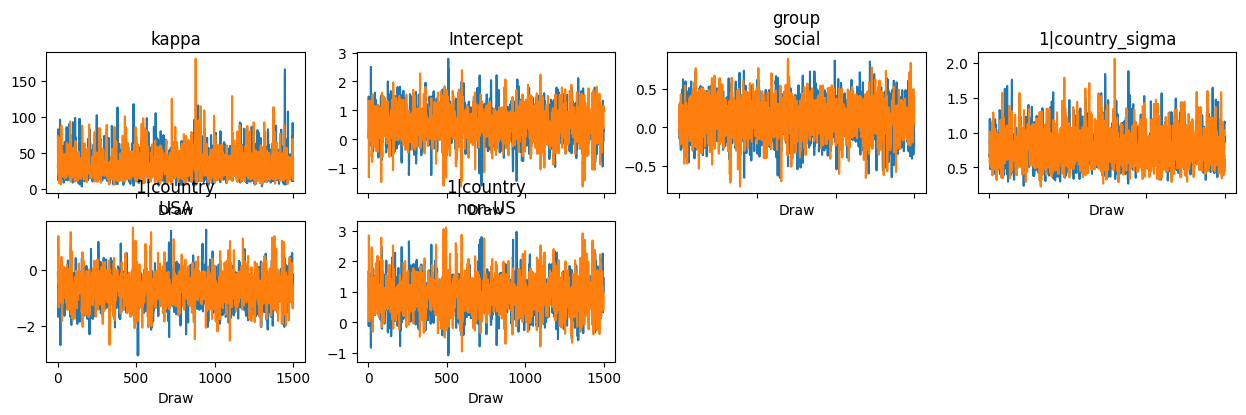

In [8]:
import arviz as az
#print(az.__version__)
import bambi as bmb
import pandas as pd

# Parameters
conf_interval = 0.9
pd.set_option("display.max_rows", None)

# Use ArviZ to plot the results
az.plot_trace(results)


#Make a summary of the parameter values by the posterior mean and 90% probability interval.

# Null hypothesis
print("null hypothesis")
pd.set_option("display.max_rows", None)
summary_null = az.summary(results_null, ci_prob=0.9).round(3)
print(summary_null)


# Key summary and diagnostic info on the model parameters
print()
print("H1 hypothesis")
pd.set_option("display.max_rows", None)
summary = az.summary(results, ci_prob=0.9).round(3)
print(summary)


print()
print("H2 hypothesis")
pd.set_option("display.max_rows", None)
summary_interaction = az.summary(results_interaction, ci_prob=0.9).round(3)
print(summary_interaction)


#Making comparisons:

print()
print("comparison")
comparison = az.compare({
    "null": results_null,
    "full1": results
})
print(comparison)

print()
print("comparison")
az.summary(results_null, ci_prob=0.9)
comparison = az.compare({
    "null": results_null,
    "full2": results_interaction
})
print(comparison)



#Formulate hypotheses for the test of the effectiveness of the intervention referring to one or several parameters within the model.





In [9]:

#Test the hypothesis using Bayesian inference.
#Calculate Bayes factor

#BF = prob_model/prob_null
#print(BF)

import numpy as np
from scipy import stats
print(list(results_interaction.posterior.data_vars))
interaction_samples = results_interaction.posterior["group:country"].values.flatten()
hierarchy_samples = results.posterior["group"].values.flatten()

# Posterior density at 0
kde = stats.gaussian_kde(hierarchy_samples)
posterior_density_at_0 = kde(0)[0]

# Prior density at 0 - fill in mu/sigma from what model_interaction printed
prior_density_at_0 = stats.norm(loc=0).pdf(0)

BF_01 = posterior_density_at_0 / prior_density_at_0
BF_10 = 1 / BF_01

print(f"BF_01 (evidence for 'no interaction/no difference' over 'same slope'): {BF_01:.3f}")
print(f"BF_10 (evidence for 'same slope' over 'no interaction'): {BF_10:.3f}")

# Posterior density at 0
kde = stats.gaussian_kde(interaction_samples)
posterior_density_at_0 = kde(0)[0]

# Prior density at 0 - fill in mu/sigma from what model_interaction printed
prior_density_at_0 = stats.norm(loc=0).pdf(0)

BF_02 = posterior_density_at_0 / prior_density_at_0
BF_20 = 1 / BF_02

print(f"BF_01 (evidence for 'no interaction/no difference' over 'different slopes'): {BF_02:.3f}")
print(f"BF_10 (evidence for 'different slopes' over 'no interaction'): {BF_20:.3f}")

['kappa', 'Intercept', 'group', 'country', 'group:country', '1|country_sigma', '1|country']
BF_01 (evidence for 'no interaction/no difference' over 'same slope'): 3.599
BF_10 (evidence for 'same slope' over 'no interaction'): 0.278
BF_01 (evidence for 'no interaction/no difference' over 'different slopes'): 0.911
BF_10 (evidence for 'different slopes' over 'no interaction'): 1.097


There were three hypotheses:
H0: Stated norms have no impact.
H1: Stated norms have the same impact in US countries and non-us countries.
H2: Stated norms have different impacts in US countries and non-us countries.

Overall, I could not find compelling reason to reject H0; while H2 is the more likely model, a Bayes factor of 1.1 is not significant at all. You need something above 3.

I can say, however, that H1 seems like an unlikely model; H0 has a Bayes factor of 3.6 over H1, more than three times worse than the null hypothesis.

Many of the calculated variables, in all models, have a zero within their confidence interval, which is bad.

With more data available, these calculations might get different results.

Setting more specific priors might also be helpful.

In [11]:
!jupyter nbconvert --execute --to html "/content/Bern02_hierarchical_models_and_testing(1).ipynb"

[NbConvertApp] Converting notebook /content/Bern02_hierarchical_models_and_testing(1).ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 499107 bytes to /conten